In [1]:
# numpy: 수치 계산 및 가상의 박막 두께 데이터 생성
# matplotlib: 웨이퍼 두께 분포 시각화
# griddata: 측정 지점 사이의 값을 보간하여 연속적인 Wafer Map 생성

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [2]:
# 웨이퍼 위의 49개 측정 지점 생성
# x축 7개 × y축 7개 = 총 49개 지점

x_points = [-80, -60, -40, 0, 40, 60, 80]
y_points = [-80, -60, -40, 0, 40, 60, 80]

coords_x = []
coords_y = []

for y in y_points:
    for x in x_points:
        coords_x.append(x)
        coords_y.append(y)

print("측정 지점 개수:", len(coords_x))

측정 지점 개수: 49


In [3]:
# 결과를 다시 실행해도 동일하게 재현하기 위해 난수 고정
np.random.seed(42)

# 실제 측정값이 없으므로 평균 100Å 주변의 가상 두께 데이터 생성
# 평균 = 100Å
# 표준편차 = 1.5Å
# 데이터 개수 = 49개

thickness = np.random.normal(
    loc=100,
    scale=1.5,
    size=len(coords_x)
)

print("평균 두께:", round(thickness.mean(), 2), "Å")
print("최소 두께:", round(thickness.min(), 2), "Å")
print("최대 두께:", round(thickness.max(), 2), "Å")

평균 두께: 99.71 Å
최소 두께: 97.06 Å
최대 두께: 102.78 Å


In [4]:
# 박막 두께 Spec 설정
target = 100
tolerance = 5

lower_spec = target - tolerance
upper_spec = target + tolerance

# 각 측정값이 95Å ~ 105Å 범위에 있는지 확인
within_spec = (
    (thickness >= lower_spec) &
    (thickness <= upper_spec)
)

print("Spec 범위:", lower_spec, "~", upper_spec, "Å")
print("Spec 만족 지점:", within_spec.sum(), "/", len(thickness))

Spec 범위: 95 ~ 105 Å
Spec 만족 지점: 49 / 49


In [5]:
# 웨이퍼 맵을 부드럽게 표현하기 위한 격자 생성
# -100 ~ 100 범위를 각각 200개 지점으로 나눔

xi = np.linspace(-100, 100, 200)
yi = np.linspace(-100, 100, 200)

# 49개의 실제 측정 지점 사이 값을 보간
# cubic = 주변 측정값을 이용해 부드럽게 연결

zi = griddata(
    (coords_x, coords_y),
    thickness,
    (xi[None, :], yi[:, None]),
    method='cubic'
)

In [6]:
# 사각형 그래프가 아니라 실제 웨이퍼처럼 원형으로 표시하기 위한 마스크
# 중심으로부터 일정 거리보다 바깥쪽인 부분은 NaN 처리

X, Y = np.meshgrid(xi, yi)

wafer_radius = 100

mask = np.sqrt(X**2 + Y**2) > wafer_radius

zi[mask] = np.nan

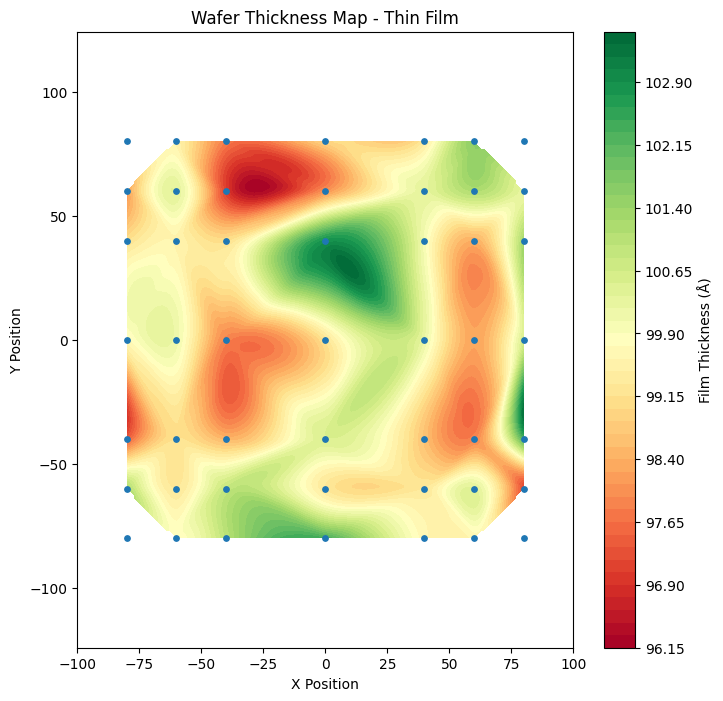

In [7]:
# 박막 두께의 웨이퍼 내 분포를 Contour Map으로 시각화

plt.figure(figsize=(8, 8))

contour = plt.contourf(
    xi,
    yi,
    zi,
    levels=50,
    cmap='RdYlGn'
)

# 두께값을 색상으로 표현
plt.colorbar(
    contour,
    label='Film Thickness (Å)'
)

# 실제 49개 측정 위치도 함께 표시
plt.scatter(
    coords_x,
    coords_y,
    s=15
)

plt.title('Wafer Thickness Map - Thin Film')
plt.xlabel('X Position')
plt.ylabel('Y Position')

# X/Y축 비율을 동일하게 설정
plt.axis('equal')

plt.show()

In [8]:
# 보간된 웨이퍼 데이터 중 NaN이 아닌 값만 사용
valid = zi[~np.isnan(zi)]

# Non-Uniformity 계산
# 값이 작을수록 웨이퍼 전체의 박막 두께가 균일하다는 의미

non_uniformity = (
    (valid.max() - valid.min())
    / (2 * valid.mean())
    * 100
)

print(f"Maximum Thickness: {valid.max():.2f} Å")
print(f"Minimum Thickness: {valid.min():.2f} Å")
print(f"Mean Thickness: {valid.mean():.2f} Å")
print(f"Non-Uniformity: {non_uniformity:.2f}%")

Maximum Thickness: 103.47 Å
Minimum Thickness: 96.16 Å
Mean Thickness: 99.60 Å
Non-Uniformity: 3.67%


In [9]:
# Non-Uniformity가 낮을수록 웨이퍼 내 박막 두께가 균일함
# 실제 합격 기준은 공정 및 제품 Spec에 따라 달라질 수 있음

if non_uniformity < 3:
    print("박막 두께가 비교적 균일한 분포를 보입니다.")
else:
    print("박막 두께 편차가 비교적 크게 나타납니다.")

박막 두께 편차가 비교적 크게 나타납니다.
